# 项目：可视化帕默群岛企鹅数据

## 分析目标

此数据分析报告的目的是对帕默群岛上企鹅样本的相关变量进行可视化，从而探索和分析种类、性别、所在岛屿等因素，与企鹅的身体属性，包括体重、嘴峰长度和深度、鳍的长度，之间的关系。

## 简介

原始数据`Penguins.csv`包括334个收集自南极洲帕尔默群岛的3个岛屿上的企鹅样本，以及企鹅相关属性数据，包括种类名、所在岛、嘴峰长度、嘴峰深度、鳍长度、体重、性别。

`Penguins.csv`每列的含义如下：
- `species`：企鹅的种类

- `island`：企鹅所在岛

- `culmen_length_mm`：企鹅嘴峰的长度（单位为毫米）
- `culmen_depth_mm`：企鹅嘴峰的深度（单位为毫米）
- `flipper_length_mm`：企鹅鳍的长度（单位为毫米）
- `body_mass_g`：企鹅体重（单位为克）
- `sex`：企鹅性别

## 数据读取

首先导入本次数据分析所需要用到的Python库，`numpy`和`pandas`主要用于前期的数据读取、评估及清洗，`matplotlib`和`seaborn`用于后续的数据可视化。

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

利用`pandas`的`read_csv`函数读取原始文件`penguins.csv`，将得到的DataFrame命名为`original_penguins_data`。

In [3]:
original_penguins_data = pd.read_csv("penguins.csv")
original_penguins_data.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


## 数据评估及清洗

首先进行数据评估，分别从数据的整齐度和数据的干净度两方面进行`origin_penguins_data`的结构性和内容性问题进行评估。

### 数据的整齐度

对于数据的整齐度，主要从三个方面进行评估，即数据需满足“每列是一个变量，每行是一个观察值，每个单元格只有一个值”。我们随机选取10行进行初步观察。

In [4]:
original_penguins_data.sample(10)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
94,Adelie,Dream,36.2,17.3,187.0,3300.0,FEMALE
49,Adelie,Dream,42.3,21.2,191.0,4150.0,MALE
264,Gentoo,Biscoe,50.5,15.9,222.0,5550.0,MALE
181,Chinstrap,Dream,52.8,20.0,205.0,4550.0,MALE
68,Adelie,Torgersen,35.9,16.6,190.0,3050.0,FEMALE
41,Adelie,Dream,40.8,18.4,195.0,3900.0,MALE
245,Gentoo,Biscoe,46.1,15.1,215.0,5100.0,MALE
311,Gentoo,Biscoe,52.2,17.1,228.0,5400.0,MALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
310,Gentoo,Biscoe,47.5,15.0,218.0,4950.0,FEMALE


经5次随机抽取10行进行观察，该数据集均满足“每列是一个变量，每行是一个观察值，每个单元格只有一个值”的数据结构性要求。

### 数据的干净度

对于数据的内容性问题主要有：数据的缺失、重复、不一致以及无效或错误问题。对于不同问题的清洗需根据数据分析的目的进行处理。

首先，对于数据集的整体信息进行了解，更直观的查找是否存在数据缺失和不一致的情况，进而进行处理。

In [5]:
original_penguins_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


可见，`original_penguins_data`共有344个观察值，其中`culmen_length_mm`、`culmen_depth_mm`、`flipper_length_mm`、`body_mass_g`、`sex`数据均存在缺失。此外，`species`、`island`、
`sex`均为分类变量，其数据类型应为`category`类型，后续需进行更改。

#### 数据缺失

本次数据分析的目的是探索和分析种类、性别、所在岛屿等因素，与企鹅的身体属性，包括体重、嘴峰长度和深度、鳍的长度，之间的关系，则`culmen_length_mm`、`culmen_depth_mm`、`flipper_length_mm`、`body_mass_g`、`sex`应均不存在缺失，故对于缺失`culmen_length_mm`、`culmen_depth_mm`、`flipper_length_mm`、`body_mass_g`、`sex`的观察值应进行删除处理。

为保持原始数据的不被修改，以便于后续进行回溯，将`original_penguins_data`赋值给一个新的DataFrame，并命名为`cleaned_penguins_data`。

In [6]:
cleaned_penguins_data = original_penguins_data.copy()
cleaned_penguins_data.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


删除缺失`culmen_length_mm`、`culmen_depth_mm`、`flipper_length_mm`、`body_mass_g`、`sex`的观察值。

In [7]:
cleaned_penguins_data.dropna(subset=["culmen_length_mm", "culmen_depth_mm", "flipper_length_mm", "body_mass_g", "sex"], inplace=True)

检查缺失`culmen_length_mm`、`culmen_depth_mm`、`flipper_length_mm`、`body_mass_g`、`sex`的观察值是否已完全删除。

In [8]:
cleaned_penguins_data.query("culmen_length_mm.isnull() | culmen_depth_mm.isnull() | flipper_length_mm.isnull() | body_mass_g.isnull() | sex.isnull()")

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex


经检查，缺失`culmen_length_mm`、`culmen_depth_mm`、`flipper_length_mm`、`body_mass_g`、`sex`的观察值均已完全删除。

#### 数据重复

由初步分析，该数据集中的每个变量对于本次数据分析均不可重复，故首先查看是否存在重复的观察值。

In [9]:
cleaned_penguins_data[cleaned_penguins_data.duplicated()]

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex


无重复观察值，无需进行处理。

#### 数据不一致

`species`、`island`、`sex`可能存在数据不一致。分别查看各自的值，并将其数据类型转化为`category`类型。我们先使用`value_counts()`方法对数据不一致进行评估和清洗，而后进行数据类型的转化。

In [10]:
cleaned_penguins_data["species"].value_counts()

species
Adelie       146
Gentoo       120
Chinstrap     68
Name: count, dtype: int64

`species`满足数据一致要求，下面进行数据类型的转换。

In [11]:
cleaned_penguins_data["species"] = cleaned_penguins_data["species"].astype("category")

In [12]:
cleaned_penguins_data["species"]

0      Adelie
1      Adelie
2      Adelie
4      Adelie
5      Adelie
        ...  
338    Gentoo
340    Gentoo
341    Gentoo
342    Gentoo
343    Gentoo
Name: species, Length: 334, dtype: category
Categories (3, object): ['Adelie', 'Chinstrap', 'Gentoo']

对`species`的数据一致性评估及清洗操作完毕，并完成数据类型的转换，对`island`进行数据一致性的评估。

In [13]:
cleaned_penguins_data["island"].value_counts()

island
Biscoe       164
Dream        123
Torgersen     47
Name: count, dtype: int64

`island`数据满足数据一致性要求，下面进行数据类型的转换。

In [14]:
cleaned_penguins_data["island"] = cleaned_penguins_data["island"].astype("category")

In [15]:
cleaned_penguins_data["island"]

0      Torgersen
1      Torgersen
2      Torgersen
4      Torgersen
5      Torgersen
         ...    
338       Biscoe
340       Biscoe
341       Biscoe
342       Biscoe
343       Biscoe
Name: island, Length: 334, dtype: category
Categories (3, object): ['Biscoe', 'Dream', 'Torgersen']

对`island`的数据一致性评估及清洗操作完毕，并完成数据类型的转换，对`sex`变量进行数据一致性的评估。

In [16]:
cleaned_penguins_data["sex"].value_counts()

sex
MALE      168
FEMALE    165
.           1
Name: count, dtype: int64

`species`和`island`均符合数据一致的要求，但`sex`存在不一致，需进行删除操作。

In [17]:
cleaned_penguins_data = cleaned_penguins_data.query("sex != '.'")

验证是否已删除成功。

In [18]:
cleaned_penguins_data.query("sex == '.'")

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex


In [19]:
cleaned_penguins_data["sex"] = cleaned_penguins_data["sex"].astype("category")

In [20]:
cleaned_penguins_data["sex"]

0        MALE
1      FEMALE
2      FEMALE
4      FEMALE
5        MALE
        ...  
338    FEMALE
340    FEMALE
341      MALE
342    FEMALE
343      MALE
Name: sex, Length: 333, dtype: category
Categories (2, object): ['FEMALE', 'MALE']

`species`、`island`、`sex`已完成数据不一致的评估和清洗，其数据类型均已转化为`category`类型。

#### 数据无效或错误

首先使用pandas的`describe`方法进行`cleaned_penguins_data`中数值变量的合理性进行评估。

In [21]:
cleaned_penguins_data.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057
std,5.468668,1.969235,14.015765,805.215802
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.600000,18.700000,213.000000,4775.000000
max,59.600000,21.500000,231.000000,6300.000000


经观察，`cleaned_penguins_data`变量中无异常数据，无需进行无效或错误数据的清洗。

数据评估及清洗已全部完成，对于本数据集无需进行数据整理，下面将进行数据可视化操作。

## 数据可视化

本次数据分析的目的在于通过对`cleaned_penguins_data`中相关变量进行数据可视化，进而探索和分析种类、性别、所在岛屿等因素，与企鹅的身体属性，包括体重、嘴峰长度和深度、鳍的长度，之间的关系。

设置图表色盘为`colorblind`。

In [24]:
sns.set_palette("colorblind")

In [25]:
cleaned_penguins_data

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,FEMALE
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


首先对`species`、`island`、`sex`3个分类变量进行可视化操作，查看原始样本数据在种类、所属岛屿及性别中的比例。选择饼图进行查看。

### 企鹅种类比例

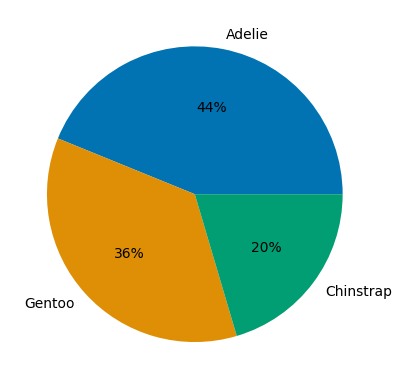

In [35]:
penguins_species_count = cleaned_penguins_data["species"].value_counts()
plt.pie(penguins_species_count, autopct="%.0f%%", labels=penguins_species_count.index)
plt.show()

可见，本数据集中`Adelie`类企鹅最多，`Gentoo`类企鹅次之，`Chinstrap`类最少。

### 企鹅所属岛屿比例

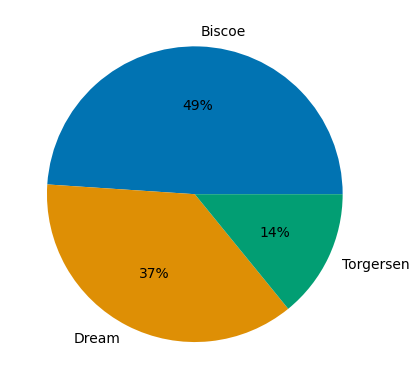

In [36]:
penguins_island_count = cleaned_penguins_data["island"].value_counts()
plt.pie(penguins_island_count, labels=penguins_island_count.index, autopct="%.0f%%")
plt.show()

所选取的样本中，来自`Biscoe`的企鹅数量最多，占总样本的一半左右；来自`Dream`的次之；来自`Torgersen`的最少，仅为`14%`。

### 企鹅性别比例

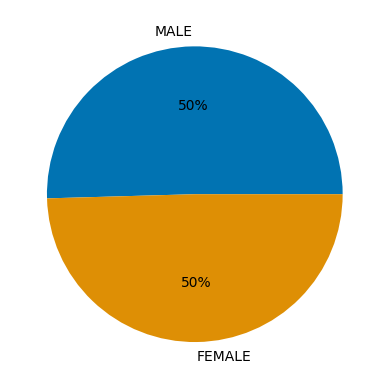

In [37]:
penguins_sex_count = cleaned_penguins_data["sex"].value_counts()
plt.pie(penguins_sex_count, labels=penguins_sex_count.index, autopct="%.0f%%")
plt.show()

本次所抽取的样本性别各占`50%`，符合随机取样。

### 企鹅种类在不同岛屿上的分布

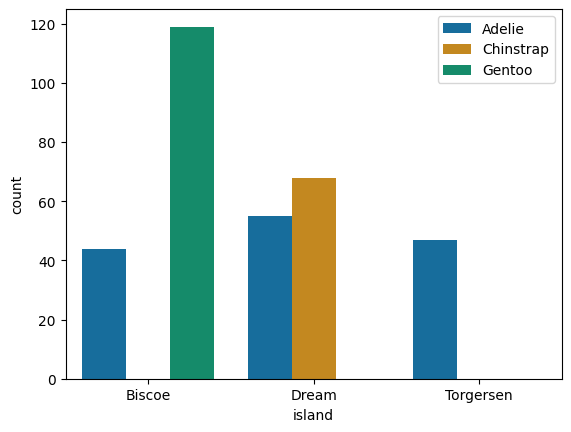

In [43]:
sns.countplot(data=cleaned_penguins_data, x=cleaned_penguins_data["island"], hue="species")
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

可见，`Adelie`类企鹅在3座岛屿上均有分布，且各岛屿上数量相差不大；`Chinstrap`类企鹅只在`Dream`有分布；`Gentoo`类企鹅只在`Biscoe`上分布。

### 企鹅性别在不同种类中的分布

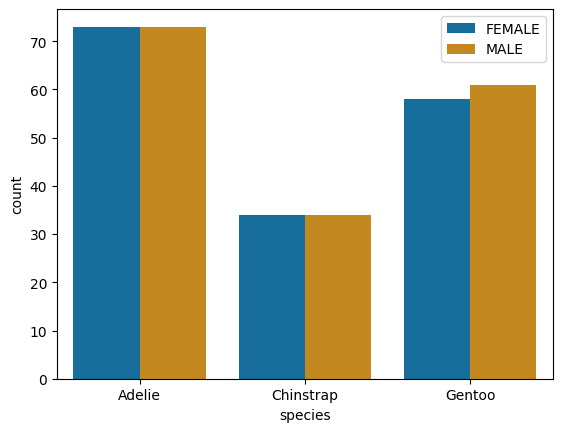

In [44]:
sns.countplot(data=cleaned_penguins_data, x=cleaned_penguins_data["species"], hue="sex")
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

在每一类企鹅中，企鹅的性别比例基本持平。

### 企鹅性别在不同岛屿上的分布

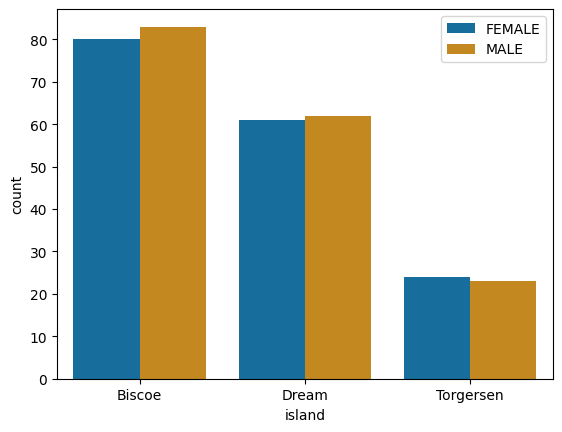

In [45]:
sns.countplot(data=cleaned_penguins_data, x=cleaned_penguins_data["island"], hue="sex")
plt.legend(bbox_to_anchor=(1,1))
plt.show()

在每个岛屿上，企鹅的性别比例持平。

### 查看数值之间的相关关系

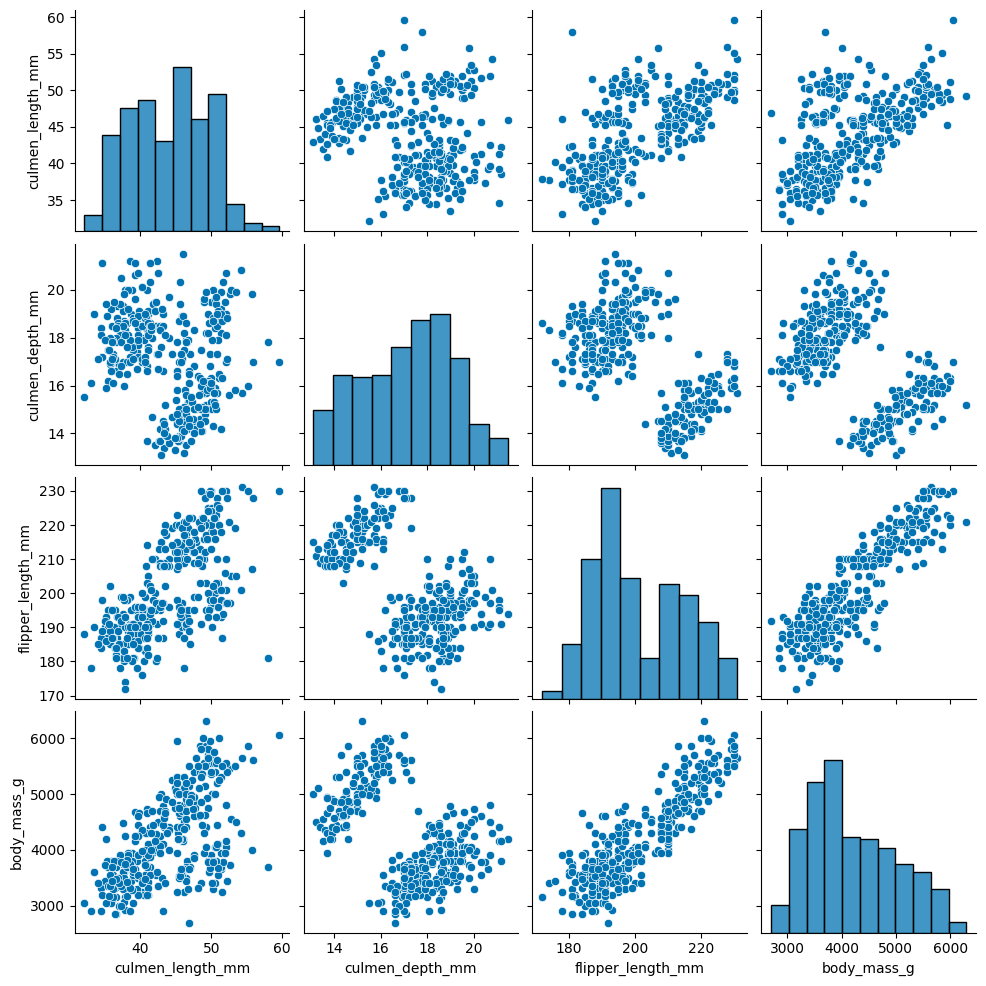

In [46]:
sns.pairplot(cleaned_penguins_data)
plt.show()

从直方图可以看出，`culmen_length_mm`、`culmen_depth_mm`、`flipper_length_mm`、`body_mass_g`均不符合正态分布。一方面说明，这里可能包含了多组存在差异的样本数据，另一方面也说明，所抽取的样本数据不够大。

从散点图可以看出，每两个数值变量之间存在多个集群，可能受`species`、`island`、`sex`等因素的影响，可以基于此做进一步的分类分析。

### 根据种类查看不同数值之间的相关关系

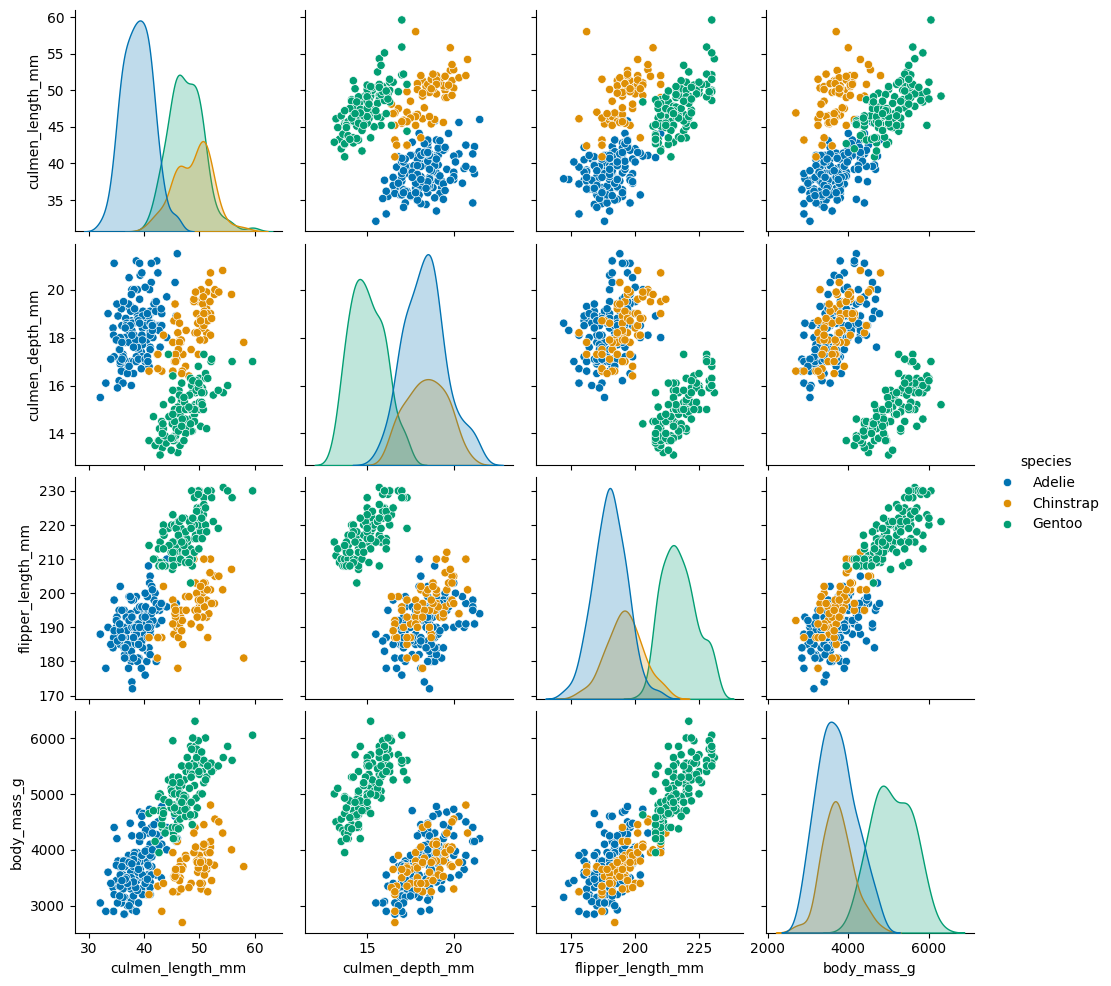

In [48]:
sns.pairplot(cleaned_penguins_data, hue="species")
plt.show()

对于同一种类的企鹅样本数据，在散点图上呈现单独的集群，说明同一种类的企鹅在`culmen_length_mm`、`culmen_depth_mm`、`flipper_length_mm`、`body_mass_g`上存在相似性。

这样有利于我们根据`culmen_length_mm`、`culmen_depth_mm`、`flipper_length_mm`、`body_mass_g`等数据推断企鹅种类。

另外，也有利于我们根据企鹅的种类推测`culmen_length_mm`、`culmen_depth_mm`、`flipper_length_mm`、`body_mass_g`等数据。

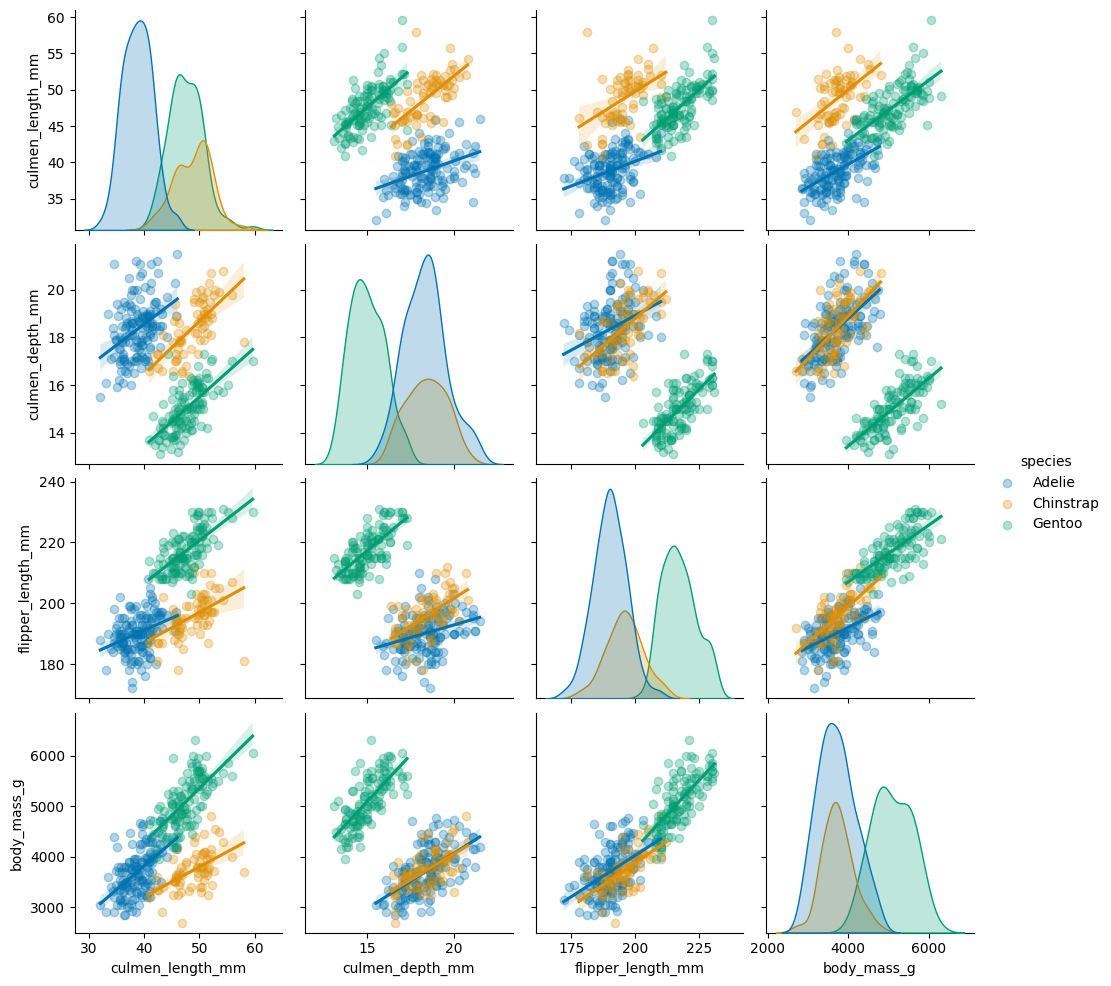

In [50]:
sns.pairplot(cleaned_penguins_data, hue="species", kind="reg", plot_kws={"scatter_kws":{"alpha":0.3} })
plt.show()

散点图结合线性回归线分析，`culmen_length_mm`、`culmen_depth_mm`、`flipper_length_mm`、`body_mass_g`两两之间呈现正相关关系，即：嘴峰越长、嘴峰越深、鳍越长、体重越重；嘴峰越短、嘴峰越浅、鳍越短、体重越轻。

从密度图也可得以下几点认识：

- `Chinstrap`和`Gentoo`两类企鹅的嘴峰长度范围基本一致，`Adelie`类企鹅的嘴峰长度最短；

- `Adelie`和`Chinstrap`两类企鹅的嘴峰深度范围基本一致，`Gentoo`类企鹅的嘴峰深度更浅；

- `Adelie`和`Chinstrap`两类企鹅的鳍长范围基本一致，`Gentoo`类企鹅的鳍长更长；

- `Adelie`和`Chinstrap`两类企鹅的体重范围基本一致，`Gentoo`类企鹅的体重更重；

但不同种类企鹅的属性数据是否存在统计显著性差异，仍然需要进行假设检验后才能得到结论。

### 根据性别查看数值之间的相关关系

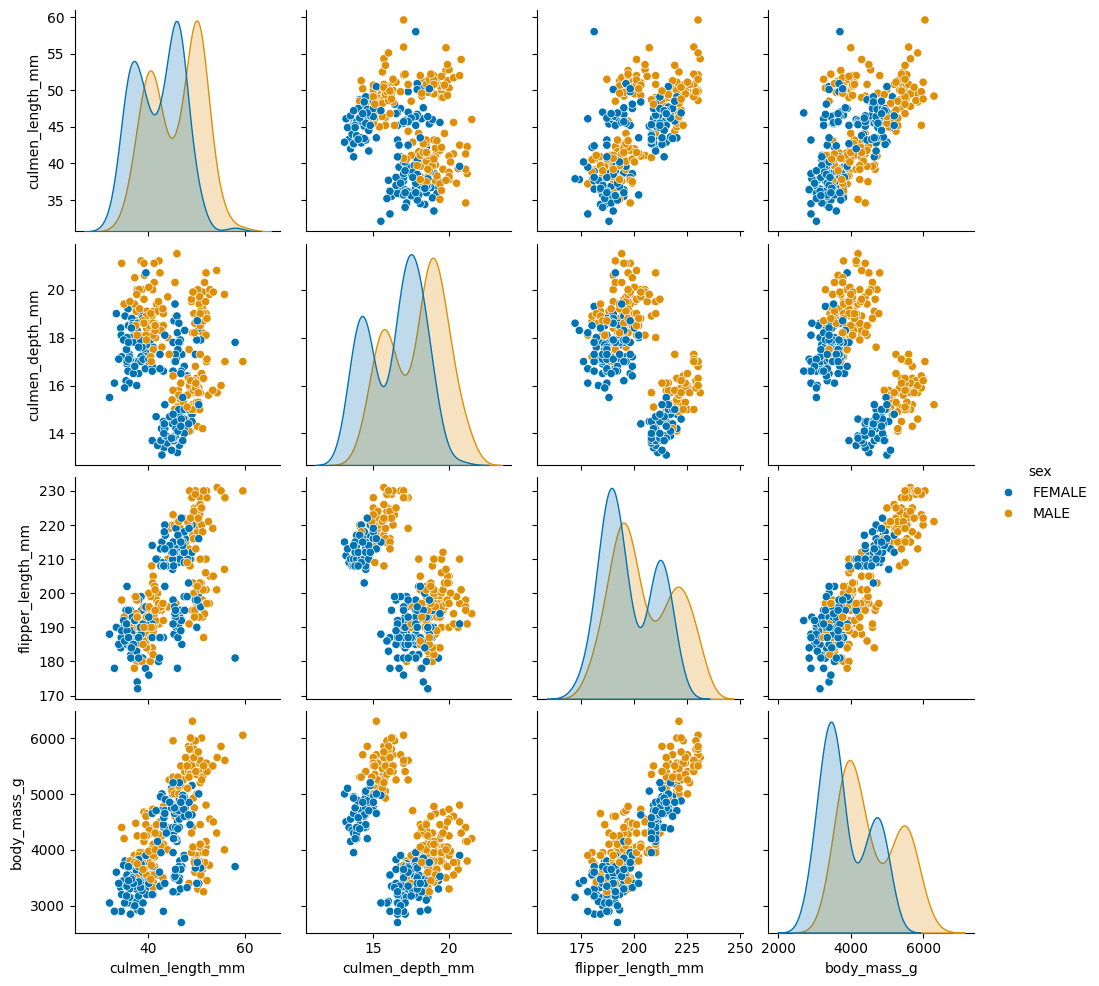

In [51]:
sns.pairplot(cleaned_penguins_data, hue="sex")
plt.show()

根据性别划分后，可以发现，雄性企鹅的各项属性数值均大于雌性企鹅。

### 根据所属岛屿查看数值之间的相关关系

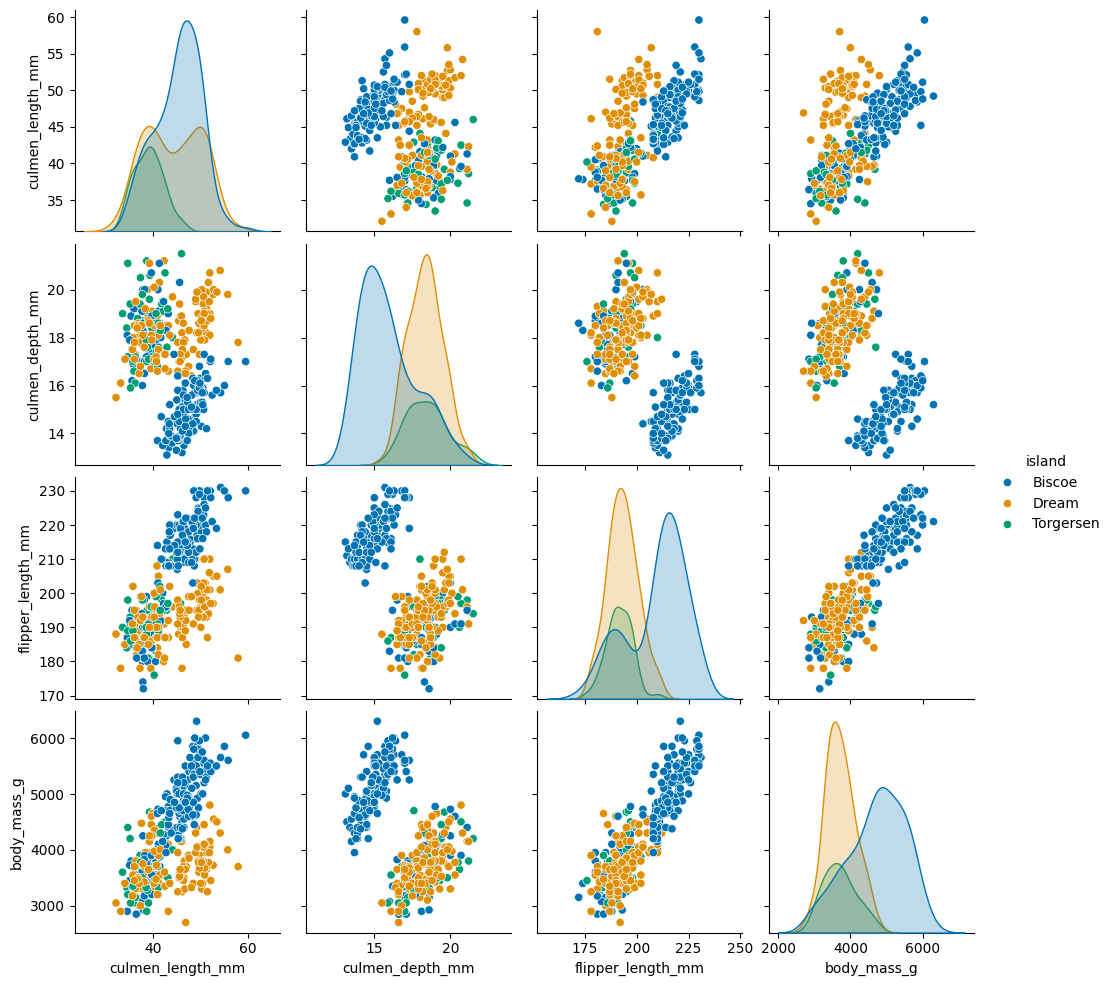

In [52]:
sns.pairplot(cleaned_penguins_data, hue="island")
plt.show()

根据所属岛屿划分后，从得到的密度图和散点图中均不能查找到某种规律，说明企鹅相关属性之间更多的取决于种类和性别。